# Safety Experiment Results Visualization

This notebook visualizes the results from the safety classification experiment.
Results are loaded from JSONL files in `data/safety_experiment/`.

In [25]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [26]:
# ---------------------------------------------------------------------------
# Fetch results from W&B if not already present locally.
# This makes the notebook work from any machine — data is downloaded once
# and cached; subsequent runs use the local copy.
# If the W&B artifact is not yet uploaded or unavailable, a warning is shown
# and the notebook falls back to whatever local data exists.
# ---------------------------------------------------------------------------
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("../../.env"))
sys.path.insert(0, str(Path("../../src")))

from intention_jailbreak.model_generation.artifacts import download_results

REGISTRY_PROJECT = "intention-jailbreak-models"
DATA_DIR = Path("../../data/safety_experiment")
GPTOSS_AUTO_DOWNLOAD = os.getenv("GPTOSS_AUTO_DOWNLOAD", "0") == "1"

def _has_jsonl(path: Path) -> bool:
    return path.exists() and any(path.rglob("*.jsonl"))

def _try_download(artifact_name, registry_project, target_dir):
    try:
        return download_results(artifact_name, registry_project, target_dir)
    except Exception as e:
        print(f"WARNING: Could not download '{artifact_name}' from W&B ({e}). Using local data if available.")
        return target_dir

# Prompting baselines (vanilla, CoT, LlamaGuard, WildGuard)
if _has_jsonl(DATA_DIR / "annotated-intents"):
    RESULTS_DIR = DATA_DIR
    print(f"Baselines: using local data at {RESULTS_DIR}")
else:
    RESULTS_DIR = _try_download("safety-experiment-baselines", REGISTRY_PROJECT, DATA_DIR)
    print(f"Baselines: downloaded to {RESULTS_DIR}")

# SFT fine-tuned baselines
if _has_jsonl(DATA_DIR / "sft" / "annotated-intents"):
    SFT_RESULTS_DIR = DATA_DIR / "sft"
    print(f"SFT:       using local data at {SFT_RESULTS_DIR}")
else:
    SFT_RESULTS_DIR = _try_download("safety-experiment-sft", REGISTRY_PROJECT, DATA_DIR)
    print(f"SFT:       downloaded to {SFT_RESULTS_DIR}")

# GPT-OSS-Safeguard
if _has_jsonl(DATA_DIR / "safeguard" / "annotated-intents"):
    SAFEGUARD_RESULTS_DIR = DATA_DIR / "safeguard"
    print(f"Safeguard: using local data at {SAFEGUARD_RESULTS_DIR}")
else:
    SAFEGUARD_RESULTS_DIR = _try_download("safety-experiment-safeguard", REGISTRY_PROJECT, DATA_DIR / "safeguard")
    print(f"Safeguard: downloaded to {SAFEGUARD_RESULTS_DIR}")

# GPT-OSS prompting baselines (optional; used only for the final benchmark plot).
# Disabled by default because the artifact may not exist yet, and probing W&B can be slow.
if _has_jsonl(DATA_DIR / "gpt-oss-120b" / "annotated-intents"):
    GPTOSS_RESULTS_DIR = DATA_DIR / "gpt-oss-120b"
    print(f"GPT-OSS:   using local data at {GPTOSS_RESULTS_DIR}")
elif GPTOSS_AUTO_DOWNLOAD:
    GPTOSS_RESULTS_DIR = _try_download("safety-experiment-gpt-oss-120b-baselines", REGISTRY_PROJECT, DATA_DIR / "gpt-oss-120b")
    print(f"GPT-OSS:   downloaded to {GPTOSS_RESULTS_DIR}")
else:
    GPTOSS_RESULTS_DIR = DATA_DIR / "gpt-oss-120b"
    print("GPT-OSS:   local results not found; skipping artifact download (set GPTOSS_AUTO_DOWNLOAD=1 to enable).")


Baselines: using local data at ../../data/safety_experiment
SFT:       using local data at ../../data/safety_experiment/sft
Safeguard: using local data at ../../data/safety_experiment/safeguard
GPT-OSS:   local results not found; skipping artifact download (set GPTOSS_AUTO_DOWNLOAD=1 to enable).


## Configuration

Specify which datasets, models, and conditions to include in the visualization.

In [27]:
# RESULTS_DIR and SFT_RESULTS_DIR are set by the setup cell above.

# Output directory for figures
FIGS_DIR = Path("../../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_CONDITIONS = [
    "vanilla_classification",
    "vanilla_generation",
    "vanilla_with_human_intent",
    "llamaguard_classification",
    "wildguard_classification",
    "safeguard_classification",
    "guardreasoner_classification",
    "shieldgemma_classification",
    "nemotron_classification",
    "zeroshot_cot_classification",
    "zeroshot_cot_generation",
    "zeroshot_cot_classification_with_intent",
]

PROMPTING_BASELINE_CONDITIONS = [
    "vanilla_classification",
    "vanilla_generation",
    "vanilla_with_human_intent",
    "zeroshot_cot_classification",
    "zeroshot_cot_generation",
    "zeroshot_cot_classification_with_intent",
]

GPTOSS_PROMPTING_CONDITIONS = PROMPTING_BASELINE_CONDITIONS.copy()

SFT_CONDITIONS = [
    "finetuned_generation",
    "finetuned_classification",
]

ALL_CONDITIONS = BASELINE_CONDITIONS + SFT_CONDITIONS

CONDITION_NAMES = {
    "vanilla_classification":              "Vanilla Classification",
    "vanilla_generation":                  "Vanilla Generation",
    "vanilla_with_human_intent":           "Vanilla + Human Intent",
    "vanilla_with_model_intent":           "Vanilla + Model Intent",
    "llamaguard_classification":           "LlamaGuard 4",
    "wildguard_classification":            "WildGuard",
    "safeguard_classification":            "GPT-OSS-Safeguard",
    "guardreasoner_classification":        "GuardReasoner 8B",
    "shieldgemma_classification":          "ShieldGemma 27B",
    "nemotron_classification":             "Nemotron Safety 4B",
    "zeroshot_cot_classification":         "CoT Classification",
    "zeroshot_cot_generation":             "CoT Generation",
    "zeroshot_cot_classification_with_intent": "CoT + Human Intent",
    "finetuned_generation":                "SFT Generation",
    "finetuned_classification":            "SFT Classification",
}

DATASET_NAMES = {
    "annotated_intents":  "Annotated Intents",
    "annotated-intents":  "Annotated Intents",
    "wildguardmix":       "WildguardTest",
    "xstest":             "XSTest",
    "toxic-chat":         "ToxicChat",
    "aegis":              "Aegis 2",
    "openai-moderation":  "OpenAI Moderation",
}

# Ordered list for consistent axis ordering in cross-dataset charts
DATASET_ORDER = ["Annotated Intents", "WildguardTest", "XSTest", "ToxicChat", "Aegis 2", "OpenAI Moderation", "Average"]

CONDITION_COLORS = {
    "Vanilla Classification":     "#66c2a5",
    "Vanilla Generation":         "#fc8d62",
    "Vanilla + Human Intent":     "#8da0cb",
    "Vanilla + Model Intent":     "#e78ac3",
    "LlamaGuard 4":               "#e5c494",
    "WildGuard":                  "#b3b3b3",
    "GPT-OSS-Safeguard":          "#2166ac",
    "GuardReasoner 8B":           "#f46d43",
    "ShieldGemma 27B":            "#4dac26",
    "Nemotron Safety 4B":         "#76b7b2",
    "CoT Classification":         "#d73027",
    "CoT Generation":             "#762a83",
    "CoT + Human Intent":         "#1a9850",
    "SFT Generation":             "#a6d854",
    "SFT Classification":         "#ffd92f",
    "GPT-OSS 120B (Best Prompting)": "#1f78b4",
}


## Load Results

In [28]:
def compute_metrics(results: list[dict]) -> dict:
    """Compute metrics from a list of result dictionaries."""
    tp = fp = tn = fn = 0

    for r in results:
        true_harm = r.get("true_harm_binary") or r.get("true_harm")
        pred_harm = r.get("predicted_harm")

        if true_harm is None or pred_harm is None:
            continue

        true_lower = true_harm.lower()
        pred_lower = pred_harm.lower()

        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1

    total = tp + fp + tn + fn
    accuracy  = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp)    if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn)    if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {"accuracy": accuracy, "precision": precision, "recall": recall,
            "f1": f1, "total": total, "tp": tp, "fp": fp, "tn": tn, "fn": fn}


def load_jsonl(path: Path) -> list[dict]:
    results = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                results.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"WARNING: skipping malformed line in {path.name}")
    return results


def load_results(results_dir: Path, conditions: list) -> pd.DataFrame:
    """Load all results matching the specified conditions from a results directory.
    Only loads datasets whose directory names appear in DATASET_NAMES."""
    _empty = pd.DataFrame(columns=["dataset", "model", "condition",
                                   "accuracy", "precision", "recall", "f1",
                                   "total", "tp", "fp", "tn", "fn"])
    records = []
    if not results_dir or not results_dir.exists():
        return _empty

    for dataset_dir in sorted(results_dir.iterdir()):
        if not dataset_dir.is_dir():
            continue
        dataset_key = dataset_dir.name
        if dataset_key not in DATASET_NAMES:
            continue
        dataset_name = DATASET_NAMES[dataset_key]

        for jsonl_file in sorted(dataset_dir.glob("*.jsonl")):
            filename  = jsonl_file.stem
            condition = next((c for c in conditions if filename.endswith(f"_{c}")), None)
            if condition is None:
                continue
            model_name = filename[: -len(f"_{condition}")]

            records.append({
                "dataset":   dataset_name,
                "model":     model_name,
                "condition": CONDITION_NAMES.get(condition, condition),
                **compute_metrics(load_jsonl(jsonl_file)),
            })

    return pd.DataFrame(records) if records else _empty


# Load and merge
df_baselines = load_results(RESULTS_DIR,          BASELINE_CONDITIONS)
df_sft       = load_results(SFT_RESULTS_DIR,      SFT_CONDITIONS)
df_safeguard = load_results(SAFEGUARD_RESULTS_DIR, ["safeguard_classification"])
df_gptoss    = load_results(GPTOSS_RESULTS_DIR,   GPTOSS_PROMPTING_CONDITIONS)
df = pd.concat([df_baselines, df_sft, df_safeguard, df_gptoss], ignore_index=True)

# Deduplicate: keep the last occurrence for any (dataset, model, condition) triple
df = df.drop_duplicates(subset=["dataset", "model", "condition"], keep="last")

# Drop old LlamaGuard 3 rows — we only evaluate against LlamaGuard 4
df = df[~df["model"].str.contains("Guard-3", na=False)]

print(f"Loaded {len(df)} result sets total")
print(f"  Baselines : {len(df_baselines)}")
print(f"  SFT       : {len(df_sft)}")
print(f"  Safeguard : {len(df_safeguard)}")
print(f"  GPT-OSS   : {len(df_gptoss)}")

if df.empty:
    print("\nNo results loaded — check that data directories exist or W&B artifacts are available.")
    df_main      = df.copy()
    df_guard     = df.copy()
    df_safeguard = df.copy()
    df_gptoss_best = df.copy()
else:
    df_main  = df[df["model"].str.contains("Llama-3.1", na=False)].copy()
    df_guard = df[df["model"].str.contains("Guard|wildguard|gpt-oss-safeguard|shieldgemma|nemotron", case=False, na=False)].copy()

    benchmark_datasets = ["WildguardTest", "XSTest", "ToxicChat", "Aegis 2", "OpenAI Moderation"]
    gptoss_mask = df["model"].str.contains("gpt-oss-120b", case=False, na=False) & ~df["model"].str.contains("safeguard", case=False, na=False)
    df_gptoss_candidates = df[gptoss_mask & df["dataset"].isin(benchmark_datasets)].copy()

    if df_gptoss_candidates.empty:
        df_gptoss_best = df.iloc[0:0].copy()
    else:
        gptoss_avg = (
            df_gptoss_candidates.groupby(["model", "condition"], as_index=False)["f1"]
            .mean()
            .sort_values(["f1", "condition"], ascending=[False, True])
        )
        best_gptoss_model = gptoss_avg.iloc[0]["model"]
        best_gptoss_condition = gptoss_avg.iloc[0]["condition"]
        best_gptoss_avg_f1 = gptoss_avg.iloc[0]["f1"]

        df_gptoss_best = df[
            (df["model"] == best_gptoss_model)
            & (df["condition"] == best_gptoss_condition)
            & (df["dataset"].isin(benchmark_datasets))
        ].copy()
        df_gptoss_best["condition"] = "GPT-OSS 120B (Best Prompting)"

        print(
            f"  GPT-OSS best prompting condition: {best_gptoss_condition} "
            f"(avg F1 = {best_gptoss_avg_f1:.3f})"
        )

    print(f"\n  Llama 3.1 8B: {len(df_main)} result sets")
    print(f"  Guard models: {len(df_guard)} result sets")
    print(f"  GPT-OSS best: {len(df_gptoss_best)} result sets")

df


Loaded 100 result sets total
  Baselines : 90
  SFT       : 12
  Safeguard : 3
  GPT-OSS   : 0
  GPT-OSS best prompting condition: CoT Classification (avg F1 = 0.803)

  Llama 3.1 8B: 38 result sets
  Guard models: 36 result sets
  GPT-OSS best: 5 result sets


,dataset,model,condition,accuracy,precision,recall,f1,total,tp,fp,tn,fn
0,Aegis 2,allenai_wildguard,WildGuard,0.765784,0.722016,0.919736,0.80897,1964,974,375,530,85
1,Aegis 2,google_shieldgemma-27b,ShieldGemma 27B,0.736269,0.913112,0.560078,0.694294,1930,578,55,843,454
2,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.775458,0.771529,0.829084,0.799272,1964,878,260,645,181
3,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.790224,0.818719,0.784703,0.80135,1964,831,184,721,228
4,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,CoT Classification,0.784004,0.795349,0.807365,0.801312,1963,855,220,684,204
...,...,...,...,...,...,...,...,...,...,...,...,...
100,XSTest,meta-llama_Llama-3.1-8B-Instruct,SFT Classification,0.784444,0.683274,0.96,0.798337,450,192,89,161,8
101,XSTest,meta-llama_Llama-3.1-8B-Instruct,SFT Generation,0.922222,0.931937,0.89,0.910486,450,178,13,237,22
102,Annotated Intents,openai_gpt-oss-safeguard-120b,GPT-OSS-Safeguard,0.716763,0.79661,0.559524,0.657343,173,47,12,77,37
103,WildguardTest,openai_gpt-oss-safeguard-120b,GPT-OSS-Safeguard,0.893467,0.941448,0.810345,0.870991,1699,611,38,907,143


In [29]:
# ── OOD validation results ────────────────────────────────────────────────────
# Loads from data/safety_experiment/ood_validation/ — ToxicChat (train) + Aegis 2 (val).
# Conditions requiring human-annotated intents (vanilla_with_human_intent,
# zeroshot_cot_classification_with_intent) are absent because ToxicChat/Aegis have none.
OOD_VAL_DIR = Path("../../data/safety_experiment/ood_validation")

# Prompting baselines
df_ood_baselines = load_results(OOD_VAL_DIR, BASELINE_CONDITIONS)

# Best SFT adapters selected by OOD F1 (via submit_sft_eval.py --mode test)
BEST_GEN_ADAPTER = "lr_0.0002_e_5_adapter"
BEST_CLF_ADAPTER = "lr_5e-05_e_5_adapter"
df_ood_sft_gen = load_results(OOD_VAL_DIR / "sft" / "generation" / BEST_GEN_ADAPTER, ["finetuned_generation"])
df_ood_sft_clf = load_results(OOD_VAL_DIR / "sft" / "classification" / BEST_CLF_ADAPTER, ["finetuned_classification"])

df_ood = pd.concat([df_ood_baselines, df_ood_sft_gen, df_ood_sft_clf], ignore_index=True)
print(f"OOD val results: {len(df_ood)} result sets across {df_ood['dataset'].nunique()} dataset(s)")
df_ood[["dataset", "condition", "f1"]].sort_values(["dataset", "f1"], ascending=[True, False])

OOD val results: 12 result sets across 2 dataset(s)


,dataset,condition,f1
2,Aegis 2,CoT Classification,0.833922
8,Aegis 2,SFT Generation,0.832298
1,Aegis 2,Vanilla Generation,0.824893
3,Aegis 2,CoT Generation,0.822738
0,Aegis 2,Vanilla Classification,0.819562
10,Aegis 2,SFT Classification,0.814858
9,ToxicChat,SFT Generation,0.667546
6,ToxicChat,CoT Classification,0.539604
11,ToxicChat,SFT Classification,0.521978
7,ToxicChat,CoT Generation,0.516224


## F1 Score on OOD Validation Datasets

F1 scores on ToxicChat (train split) and Aegis 2 (validation split) — datasets not seen during training, used for model selection.

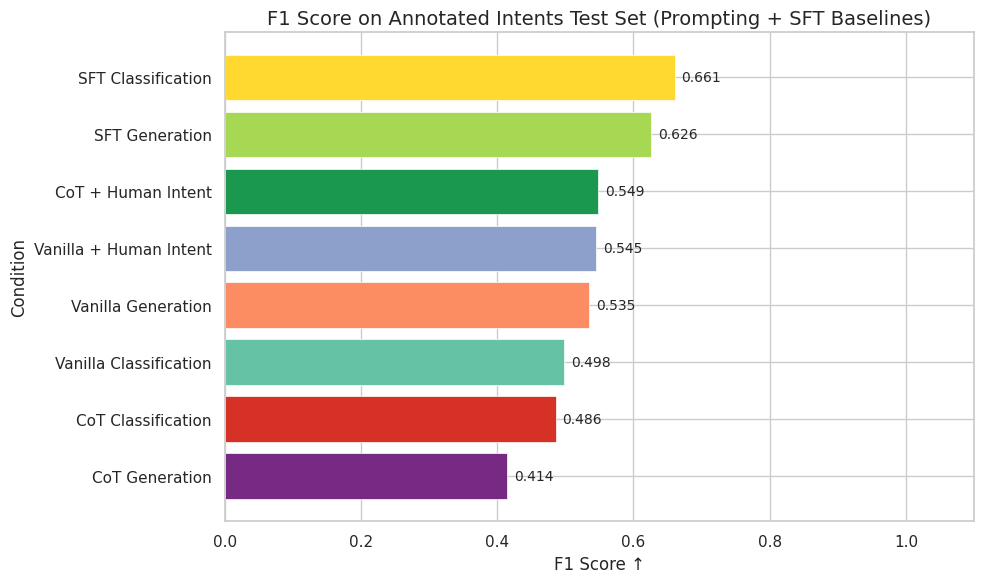

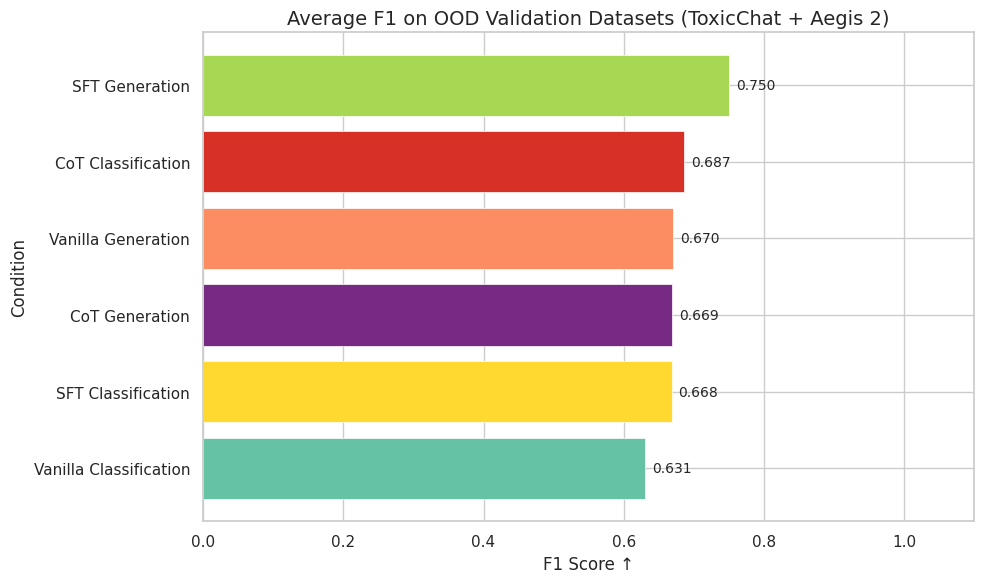

In [30]:
def plot_metric_single_dataset(df: pd.DataFrame, dataset: str, metric: str = "f1",
                                title: str = None, ascending: bool = True, save_name: str = None):
    """Plot a metric for a single dataset, ordered by the metric value."""
    df_filtered = df[df["dataset"] == dataset].copy()

    if df_filtered.empty:
        print(f"No data for dataset: {dataset}")
        return

    df_filtered = df_filtered.sort_values(metric, ascending=ascending)

    colors = [CONDITION_COLORS.get(c, "#999999") for c in df_filtered["condition"]]

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        y=df_filtered["condition"],
        width=df_filtered[metric],
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )

    for bar, val in zip(bars, df_filtered[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10)

    ax.set_xlim(0, 1.1)
    ax.set_xlabel("F1 Score ↑", fontsize=12)
    ax.set_ylabel("Condition", fontsize=12)
    ax.set_title(title or f"F1 Score on {dataset}", fontsize=14)

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# Annotated Intents test set — regular Llama prompting + SFT baselines only
annotated_conditions = [
    "Vanilla Classification",
    "Vanilla Generation",
    "Vanilla + Human Intent",
    "CoT Classification",
    "CoT Generation",
    "CoT + Human Intent",
    "SFT Generation",
    "SFT Classification",
]

df_annotated_baselines = df[
    (df["dataset"] == "Annotated Intents")
    & (df["condition"].isin(annotated_conditions))
    & (df["model"] == "meta-llama_Llama-3.1-8B-Instruct")
].copy()

plot_metric_single_dataset(
    df_annotated_baselines,
    dataset="Annotated Intents",
    metric="f1",
    title="F1 Score on Annotated Intents Test Set (Prompting + SFT Baselines)",
    ascending=True,
    save_name="f1_annotated_intents_baselines"
)


# Average F1 across OOD validation datasets (ToxicChat train + Aegis 2 val)
df_ood_avg = (
    df_ood[df_ood["dataset"].isin(["ToxicChat", "Aegis 2"])]
    .groupby("condition", as_index=False)["f1"]
    .mean()
    .sort_values("f1", ascending=True)
)

colors = [CONDITION_COLORS.get(c, "#999999") for c in df_ood_avg["condition"]]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_ood_avg["condition"], df_ood_avg["f1"], color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, df_ood_avg["f1"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel("F1 Score ↑", fontsize=12)
ax.set_ylabel("Condition", fontsize=12)
ax.set_title("Average F1 on OOD Validation Datasets (ToxicChat + Aegis 2)", fontsize=14)
plt.tight_layout()
fig.savefig(FIGS_DIR / "f1_ood_average.pdf", bbox_inches="tight")
plt.show()


## F1 Score Comparison Across All Datasets

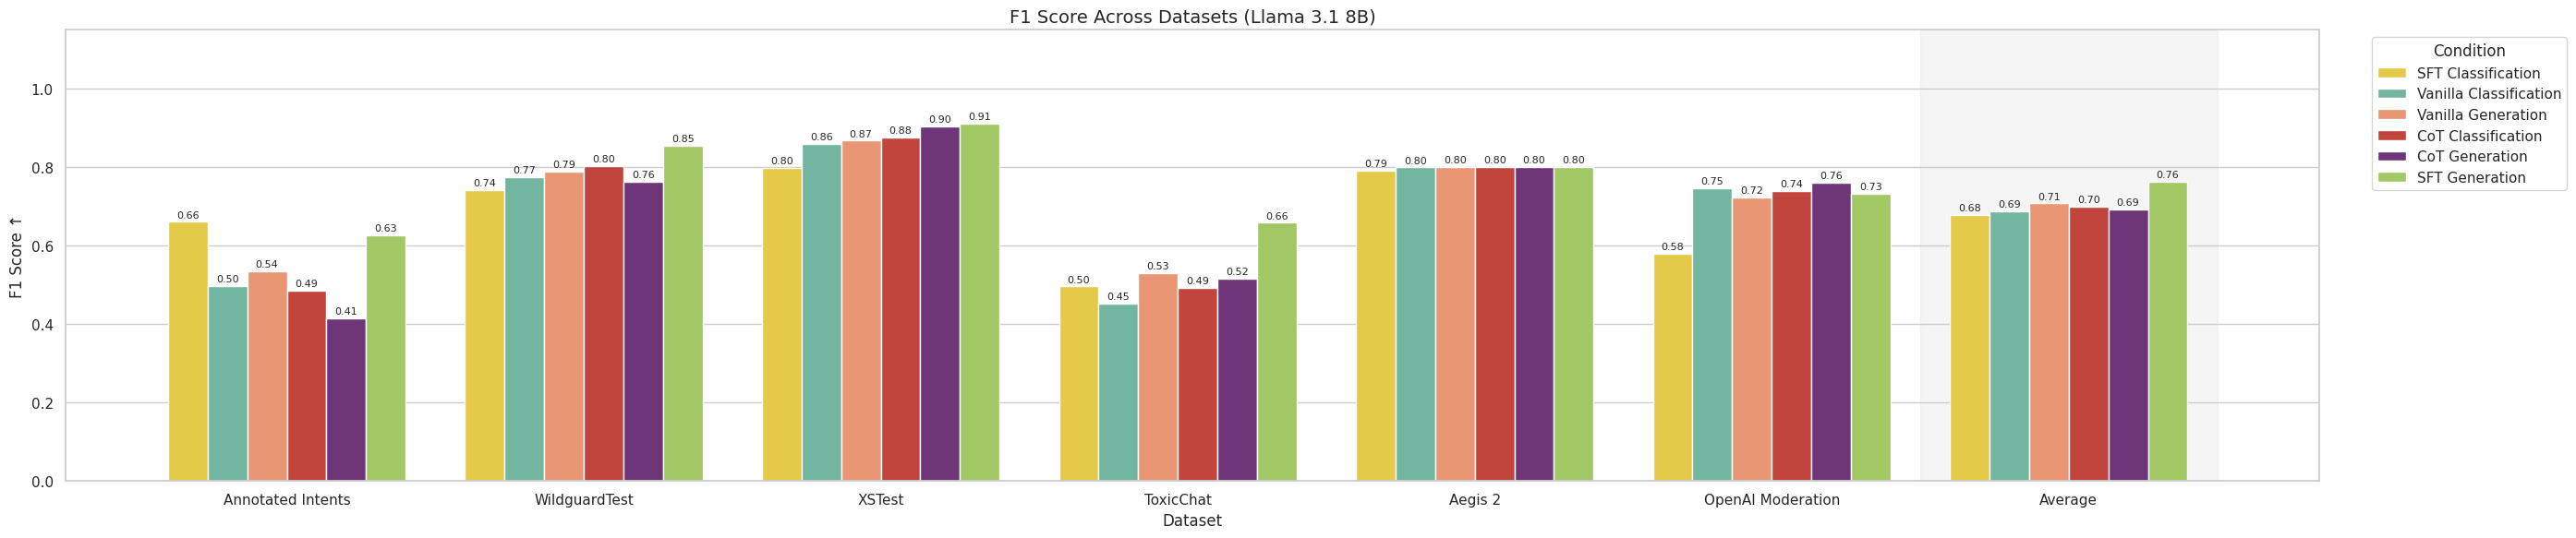

In [31]:
def add_average_group(df: pd.DataFrame, metric_cols: list = None) -> pd.DataFrame:
    """Append an 'Average' pseudo-dataset row by averaging numeric metrics across all real datasets."""
    if metric_cols is None:
        metric_cols = ["accuracy", "precision", "recall", "f1"]
    avg = (
        df.groupby(["model", "condition"])[metric_cols]
        .mean()
        .reset_index()
    )
    avg["dataset"] = "Average"
    return pd.concat([df, avg], ignore_index=True)


def plot_metric_by_dataset(df: pd.DataFrame, metric: str = "f1", exclude_conditions: list = None,
                           title: str = None, save_name: str = None):
    """Plot F1 grouped by dataset (+ Average) with consistent colors."""
    df_plot = df.copy()

    if exclude_conditions:
        df_plot = df_plot[~df_plot["condition"].isin(exclude_conditions)]

    if df_plot.empty:
        print("No data to plot")
        return

    df_plot = add_average_group(df_plot)

    # Enforce consistent dataset ordering
    present = [d for d in DATASET_ORDER if d in df_plot["dataset"].unique()]
    df_plot["dataset"] = pd.Categorical(df_plot["dataset"], categories=present, ordered=True)
    df_plot = df_plot.sort_values("dataset")

    n_datasets = len(present)
    fig, ax = plt.subplots(figsize=(4 * n_datasets, 6))

    conditions_in_data = df_plot["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}

    sns.barplot(
        data=df_plot,
        x="dataset",
        y=metric,
        hue="condition",
        ax=ax,
        palette=palette
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

    # Shade the Average column for visual separation
    avg_idx = present.index("Average") if "Average" in present else None
    if avg_idx is not None:
        ax.axvspan(avg_idx - 0.5, avg_idx + 0.5, color="grey", alpha=0.08, zorder=0)

    ax.set_title(title or "F1 Score by Dataset", fontsize=14)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_ylabel("F1 Score ↑", fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# Exclude intent-based conditions for cross-dataset comparison (not available on all datasets)
exclude = ["Vanilla + Human Intent", "Vanilla + Model Intent", "CoT + Human Intent"]

plot_metric_by_dataset(df_main, exclude_conditions=exclude,
                       title="F1 Score Across Datasets (Llama 3.1 8B)",
                       save_name="f1_comparison_all_datasets")

## Benchmark Comparison: WildguardTest and XSTest

Comparing our methods against the Wildguard paper's reported F1 scores on their benchmark datasets.

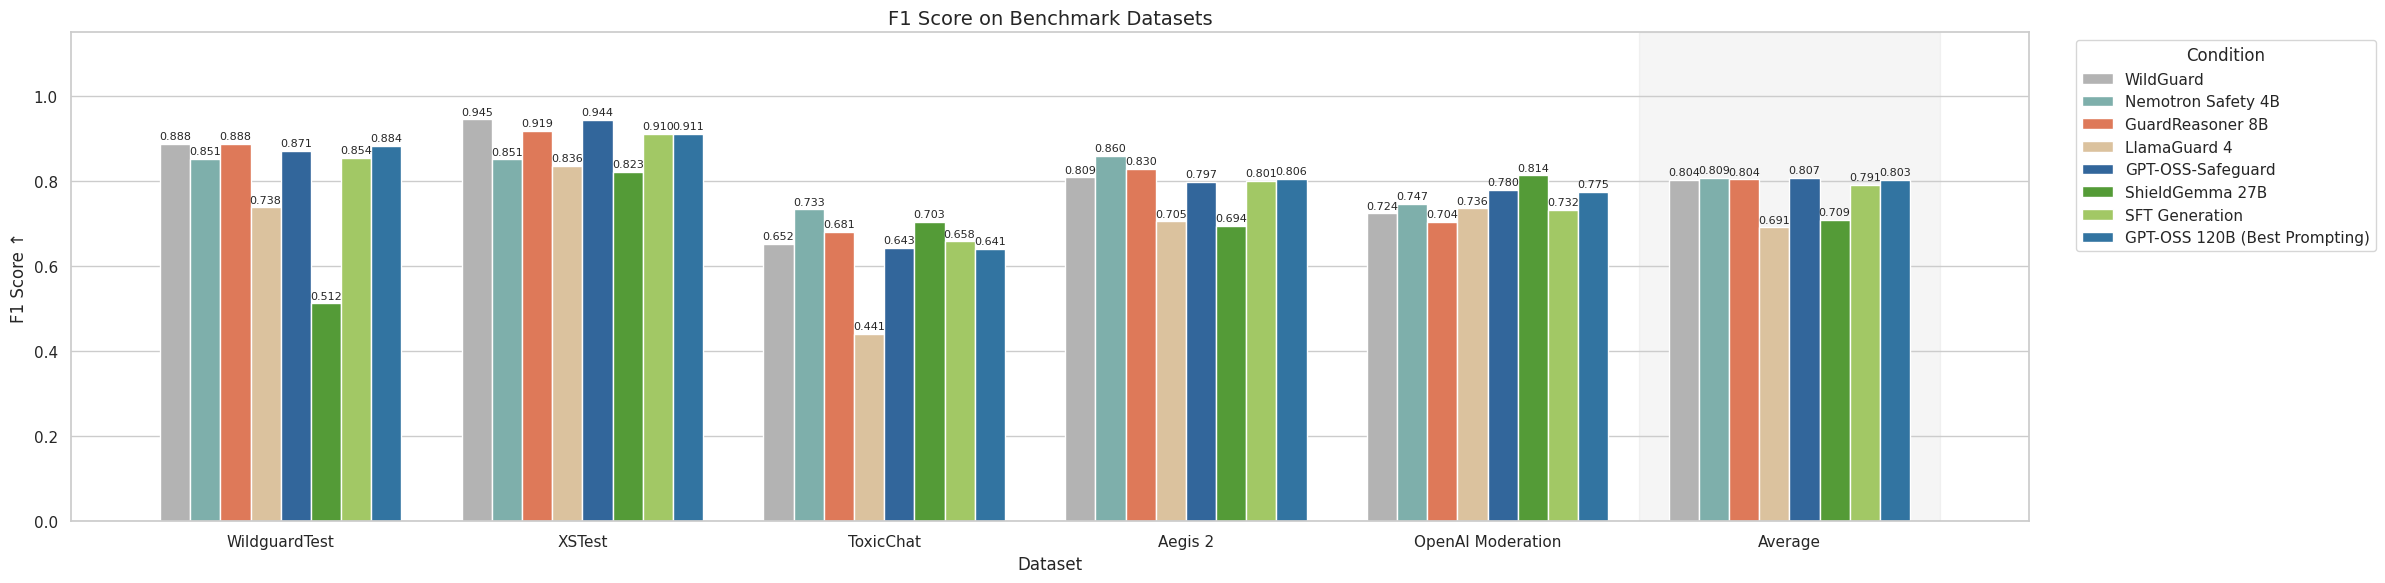

,dataset,model,condition,accuracy,precision,recall,f1,total,tp,fp,tn,fn
0,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.775458,0.771529,0.829084,0.799272,1964,878,260,645,181
1,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,Vanilla Generation,0.790224,0.818719,0.784703,0.80135,1964,831,184,721,228
2,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,CoT Classification,0.784004,0.795349,0.807365,0.801312,1963,855,220,684,204
3,Aegis 2,meta-llama_Llama-3.1-8B-Instruct,CoT Generation,0.792049,0.831804,0.770538,0.8,1962,816,165,738,243
4,Annotated Intents,meta-llama_Llama-3.1-8B-Instruct,Vanilla Classification,0.632948,0.741176,0.375,0.498024,346,63,22,156,105
...,...,...,...,...,...,...,...,...,...,...,...,...
74,Aegis 2,openai_gpt-oss-120b,GPT-OSS 120B (Best Prompting),0.792559,0.814493,0.796786,0.805542,1962,843,192,712,215
75,OpenAI Moderation,openai_gpt-oss-120b,GPT-OSS 120B (Best Prompting),0.853556,0.742958,0.809981,0.775023,1673,422,146,1006,99
76,ToxicChat,openai_gpt-oss-120b,GPT-OSS 120B (Best Prompting),0.93913,0.552209,0.763889,0.641026,5060,275,223,4477,85
77,WildguardTest,openai_gpt-oss-120b,GPT-OSS 120B (Best Prompting),0.89452,0.86514,0.903054,0.883691,1697,680,106,838,73


In [32]:
def plot_benchmark_comparison(df: pd.DataFrame, datasets: list, metric: str = "f1",
                              exclude_conditions: list = None, title: str = None, save_name: str = None):
    """Plot metric comparison for specific datasets, with an Average group appended."""
    metric_labels = {"f1": "F1 Score", "asr": "Attack Success Rate"}

    df_plot = df[df["dataset"].isin(datasets)].copy()

    if exclude_conditions:
        df_plot = df_plot[~df_plot["condition"].isin(exclude_conditions)]

    if df_plot.empty:
        print("No data to plot")
        return

    df_plot = add_average_group(df_plot)

    # Enforce consistent dataset ordering (only datasets that are present + Average)
    present = [d for d in DATASET_ORDER if d in df_plot["dataset"].unique()]
    df_plot["dataset"] = pd.Categorical(df_plot["dataset"], categories=present, ordered=True)
    df_plot = df_plot.sort_values("dataset")

    n_datasets = len(present)
    fig, ax = plt.subplots(figsize=(4 * n_datasets, 6))

    conditions_in_data = df_plot["condition"].unique()
    palette = {c: CONDITION_COLORS.get(c, "#999999") for c in conditions_in_data}

    sns.barplot(data=df_plot, x="dataset", y=metric, hue="condition", ax=ax, palette=palette)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

    # Shade the Average column for visual separation
    avg_idx = present.index("Average") if "Average" in present else None
    if avg_idx is not None:
        ax.axvspan(avg_idx - 0.5, avg_idx + 0.5, color="grey", alpha=0.08, zorder=0)

    direction = "↓" if metric == "asr" else "↑"
    ax.set_title(title or f"{metric_labels.get(metric, metric)} on Benchmark Datasets", fontsize=14)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_ylabel(f"{metric_labels.get(metric, metric)} {direction}", fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save_name:
        fig.savefig(FIGS_DIR / f"{save_name}.pdf", bbox_inches="tight")

    plt.show()


# All benchmark datasets including the new ones
benchmark_datasets = ["WildguardTest", "XSTest", "ToxicChat", "Aegis 2", "OpenAI Moderation"]

# Keep only SFT generation and guard/safeguard models to avoid crowding
exclude = [
    "Vanilla Classification",
    "Vanilla + Human Intent",
    "Vanilla + Model Intent",
    "CoT Classification",
    "CoT + Human Intent",
    "SFT Classification",
    "Vanilla Generation",
    "CoT Generation",
]

frames = [df_main, df_guard]
if 'df_gptoss_best' in globals() and not df_gptoss_best.empty:
    frames.append(df_gptoss_best)

df_benchmark = pd.concat(frames, ignore_index=True)

plot_benchmark_comparison(
    df_benchmark,
    datasets=benchmark_datasets,
    metric="f1",
    exclude_conditions=exclude,
    title="F1 Score on Benchmark Datasets",
    save_name="f1_benchmark_comparison"
)

df_benchmark
